In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# lib's

import os
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

from tensorflow.keras.applications import VGG16

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Reshape, Input
from tensorflow.keras.layers import LeakyReLU

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, cohen_kappa_score, log_loss
import seaborn as sns
import matplotlib.pyplot as plt

import joblib

from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

from PIL import Image

import json

# !pip install sentence-transformers
from sentence_transformers import SentenceTransformer, util
import torch

import csv

# -------

# !pip install pandas numpy scikit-learn xgboost lightgbm catboost -q
import pandas as pd
import numpy as np
import os
import joblib
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, cohen_kappa_score, log_loss
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
# from catboost import CatBoostClassifier

In [ ]:
# To unzip
from zipfile import ZipFile
file_name = "/content/drive/MyDrive/AWA2_dataset/AWA2_Balanced_main_dataset.zip"
with ZipFile(file_name, 'r') as zip:
  zip.extractall()
  print('done')

done


In [ ]:
!pip install split-folders

import splitfolders
splitfolders.ratio(r"/content/Trail_balanced_train_class_awa2",  # "/content/processed/train"
                   'data',
                   seed = 41,
                   ratio = (0.7, 0.15, 0.15)) # train/val/test

Copying files: 9020 files [00:50, 180.01 files/s]


In [ ]:
# variables
train_data_path = r'/content/data/train'
val_data_path = r'/content/data/val'
test_data_path =r'/content/data/test'


In [ ]:
# Load and Preprocess Images
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = datagen.flow_from_directory(train_data_path, target_size=(224, 224), batch_size=32, class_mode='categorical')
val_data = datagen.flow_from_directory(val_data_path, target_size=(224, 224), batch_size=32, class_mode='categorical')
test_data = datagen.flow_from_directory(test_data_path, target_size=(224, 224), batch_size=32, class_mode='categorical')


Found 6314 images belonging to 18 classes.
Found 1353 images belonging to 18 classes.
Found 1353 images belonging to 18 classes.


In [ ]:
# Build a DCGAN
# Generator (Feature Generator)

def build_generator(noise_dim, output_dim):
    input_noise = Input(shape=(noise_dim,))
    x = Dense(128, activation='relu')(input_noise)
    x = Dense(output_dim, activation='linear')(x)  # match feature vector size
    model = Model(input_noise, x)
    return model

# Discriminator

def build_discriminator(input_dim):
    input_feat = Input(shape=(input_dim,))
    x = Dense(128)(input_feat)
    x = LeakyReLU(alpha=0.2)(x)
    x = Dense(1, activation='sigmoid')(x)
    model = Model(input_feat, x)
    return model


In [ ]:
# Feature Extractor

def build_feature_extractor():
    base_model = VGG16(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
    return base_model

# Create the feature extractor
feature_extractor = build_feature_extractor()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Train the GAN

# Assumptions
noise_dim = 100
feature_dim = 512  # e.g., from CNN like VGG16 with global average pooling
batch_size = 128 # 64
epochs = 11 # 10000

generator = build_generator(noise_dim, feature_dim)
discriminator = build_discriminator(feature_dim)

# Compile discriminator
discriminator.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Freeze discriminator during generator training
discriminator.trainable = False

# GAN = generator + discriminator
noise_input = tf.keras.Input(shape=(noise_dim,))
generated_feature = generator(noise_input)
validity = discriminator(generated_feature)

gan = tf.keras.Model(noise_input, validity)
gan.compile(optimizer='adam', loss='binary_crossentropy')

# Prepare real feature vectors
real_features, real_labels = [], []
for X, y in train_data:
    feat = feature_extractor.predict(X)
    real_features.append(feat)
    real_labels.append(y)
    if len(real_features)*batch_size > 10000:
        break

real_features = np.vstack(real_features)
real_labels = np.argmax(np.vstack(real_labels), axis=1)

# Training loop
for epoch in range(epochs):
    # ---------------------
    # Train Discriminator
    # ---------------------
    idx = np.random.randint(0, real_features.shape[0], batch_size)
    real_feat_batch = real_features[idx]

    noise = np.random.normal(0, 1, (batch_size, noise_dim))
    fake_feat_batch = generator.predict(noise)

    # Labels
    real_y = np.ones((batch_size, 1))
    fake_y = np.zeros((batch_size, 1))

    # Train discriminator
    d_loss_real = discriminator.train_on_batch(real_feat_batch, real_y)
    d_loss_fake = discriminator.train_on_batch(fake_feat_batch, fake_y)
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # ---------------------
    # Train Generator
    # ---------------------
    noise = np.random.normal(0, 1, (batch_size, noise_dim))
    valid_y = np.ones((batch_size, 1))  # Trick GAN: fake should be labeled real

    g_loss = gan.train_on_batch(noise, valid_y)

    if epoch % 10 == 0:
        print(f"{epoch} [D loss: {d_loss[0]} | D acc.: {100*d_loss[1]:.2f}] [G loss: {g_loss:.4f}]")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py:83: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


0 [D loss: 0.5139032006263733 | D acc.: 82.62] [G loss: 0.9114]
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
10 [D loss: 2.087780475616455 | D acc.: 44.97] [G loss: 0.1510]


In [ ]:
# # train_data
# for i, (images, labels) in enumerate(train_data):
#         print(f"Batch {i+1}:")
#         print(f"  Images shape: {images.shape}")
#         print(f"  Labels shape: {labels.shape}")

In [ ]:
def feature_extraction_and_label_collection(data):
    X_features = []
    y_labels = []
    idx_to_class = {v: k for k, v in data.class_indices.items()}

    # Loop over train_data batches
    for images, labels in data:
        features = feature_extractor.predict(images)
        X_features.append(features)
        y_labels.append(np.argmax(labels, axis=1))  # assuming categorical class_mode

        # Optional: break early if too large
        if len(X_features) * data.batch_size > 10000:
            break

    # Stack all batches into arrays
    X_features = np.vstack(X_features)
    y_labels = np.concatenate(y_labels)

    features_data = pd.DataFrame(X_features)
    features_data['actual_label'] = y_labels
    features_data['actual_class'] = [idx_to_class[i] for i in features_data['actual_label']]

    return features_data

train_features_data = feature_extraction_and_label_collection(train_data)
train_features_data.to_csv('GAN_based_train_features_data.csv', index=False)
train_features_data = train_features_data.drop(columns=['actual_class'])
train_features_data.to_csv('GAN_based_train_features_data_with_actual_label.csv', index=False)

test_features_data = feature_extraction_and_label_collection(test_data)
test_features_data.to_csv('GAN_based_test_features_data.csv', index=False)
test_features_data = test_features_data.drop(columns=['actual_class'])
test_features_data.to_csv('GAN_based_test_features_data_with_actual_label.csv', index=False)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

### ML model train

In [ ]:
# ====================== 0. Create 'MLmodels' Folder ======================
def create_model_folder(folder_name="MLmodels"):
    """Create a folder to save trained models."""
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)
        print(f"Folder '{folder_name}' created.")
    else:
        print(f"Folder '{folder_name}' already exists.")
    return folder_name

def add_pred_label(file_path, y_pred, name, accuracy, folder_name="MLmodels", result_filename_env="Train"):
    df = pd.read_csv(file_path)
    df['pred_label'] = y_pred
    result_filename = f"{folder_name}/{result_filename_env}_{name}_{accuracy}.csv"
    df.to_csv(result_filename, index=False)
    print(f"Saved: {result_filename}")

# ====================== 1. Load Data ======================
def load_data(train_path, test_path, target_column="actual_label", folder_name='MLmodels'):
    """
    Load and preprocess train/test datasets.
    Args:
        train_path (str): Path to training CSV.
        test_path (str): Path to testing CSV.
        target_column (str): Name of the target variable.
        drop_column (list): Name of the drop variable.
    Returns:
        X_train, y_train, X_test, y_test (DataFrames/arrays)
    """
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)

    # Separate features and target
    X_train = train_df.drop(columns=target_column)
    y_train = train_df[target_column]
    X_test = test_df.drop(columns=target_column)
    y_test = test_df[target_column]

    # Encode categorical target if needed
    le = LabelEncoder()
    y_train = le.fit_transform(y_train)
    y_test = le.transform(y_test)

    # Save Scale model
    model_filename = f"{folder_name}/LabelEncoder_model.pkl"
    joblib.dump(le, model_filename)
    print(f"Saved: {model_filename}")

    # Scale numerical features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Save Scale model
    model_filename = f"{folder_name}/scaler_model.pkl"
    joblib.dump(scaler, model_filename)
    print(f"Saved: {model_filename}")

    return X_train, y_train, X_test, y_test

# ====================== 2. Train Models ======================
def train_models(X_train, y_train, X_test, y_test, folder_name="MLmodels"):
    """
    Train multiple classification models.
    Train models, evaluate accuracy, and save them.
    Returns:
        Dictionary of trained models.
    """
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "SVM": SVC(probability=True),
        "Decision Tree": DecisionTreeClassifier(),
        "Random Forest": RandomForestClassifier(),
        "Gradient Boosting": GradientBoostingClassifier(),
        "XGBoost": XGBClassifier(eval_metric='logloss'),
        "LightGBM": LGBMClassifier(),
        # "CatBoost": CatBoostClassifier(verbose=0),
        "AdaBoost": AdaBoostClassifier(),
        "k-NN": KNeighborsClassifier(),
        "Naive Bayes": GaussianNB(),
    }

    for name, model in models.items():
        print(f"Training {name}...")
        model.fit(X_train, y_train)

        # Evaluate accuracy
        y_pred = model.predict(X_train)
        accuracy = round(accuracy_score(y_train, y_pred), 4)
#         print(f"Train Accuracy: {accuracy}")
        add_pred_label('GAN_based_train_features_data.csv', y_pred, name, accuracy)

        y_pred = model.predict(X_test)
        accuracy = round(accuracy_score(y_test, y_pred), 4)
#         print(f"Test Accuracy: {accuracy}")
        add_pred_label('GAN_based_test_features_data.csv', y_pred, name, accuracy, result_filename_env="Test")

        # Save model with accuracy in filename
        model_filename = f"{folder_name}/{name}_{accuracy}.pkl"
        joblib.dump(model, model_filename)
        print(f"Saved: {model_filename}")
    print("\nAll models saved successfully!")

    return models

# ====================== 3. Evaluate Models ======================
def evaluate_models(models, X_test, y_test, folder_name="MLmodels", model_env="Train"):
    """
    Evaluate models and print metrics.
    """
    results = []
    for name, model in models.items():
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')
        kappa = cohen_kappa_score(y_test, y_pred)

        results.append({
            "Model": name,
            "Accuracy": round(accuracy, 4),
            "Loss": 1-round(accuracy, 4),
            "Precision": round(precision, 4),
            "Recall": round(recall, 4),
            "F1-Score": round(f1, 4),
            "Kappa Score": round(kappa, 4)
        })

    results_df = pd.DataFrame(results)
    print("\n===== Model Evaluation Results =====")
    print(results_df.sort_values(by="Accuracy", ascending=False))

    result_filename = f"{folder_name}/ML_Model_Evaluation_Results_{model_env}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
    results_df.to_csv(result_filename, index=False)
    print(f"Saved: {result_filename}")

    return results_df

# ====================== 4. Main Pipeline ======================
if __name__ == "__main__":
    # Step 0: Create folder
    models_folder = create_model_folder()

    # Load data (replace paths and target column name)
    train_path = "GAN_based_train_features_data_with_actual_label.csv"
    test_path = "GAN_based_test_features_data_with_actual_label.csv"
    target_column = "actual_label"  # Replace with your target column name

    # scaler data
    X_train, y_train, X_test, y_test = load_data(train_path, test_path, target_column)

    # Train models
    models = train_models(X_train, y_train, X_test, y_test) # train_and_save_models(X_train, y_train, X_test, y_test, models_folder)

    # Evaluate models
    Train_results_df = evaluate_models(models, X_train, y_train)
    Test_results_df = evaluate_models(models, X_test, y_test, model_env="Test")

Folder 'MLmodels' created.
Saved: MLmodels/LabelEncoder_model.pkl
Saved: MLmodels/scaler_model.pkl
Training Logistic Regression...
Saved: MLmodels/Train_Logistic Regression_1.0.csv
Saved: MLmodels/Test_Logistic Regression_0.9447.csv
Saved: MLmodels/Logistic Regression_0.9447.pkl
Training SVM...
Saved: MLmodels/Train_SVM_0.992.csv
Saved: MLmodels/Test_SVM_0.9431.csv
Saved: MLmodels/SVM_0.9431.pkl
Training Decision Tree...
Saved: MLmodels/Train_Decision Tree_1.0.csv
Saved: MLmodels/Test_Decision Tree_0.6936.csv
Saved: MLmodels/Decision Tree_0.6936.pkl
Training Random Forest...
Saved: MLmodels/Train_Random Forest_1.0.csv
Saved: MLmodels/Test_Random Forest_0.9059.csv
Saved: MLmodels/Random Forest_0.9059.pkl
Training Gradient Boosting...
Saved: MLmodels/Train_Gradient Boosting_1.0.csv
Saved: MLmodels/Test_Gradient Boosting_0.8962.csv
Saved: MLmodels/Gradient Boosting_0.8962.pkl
Training XGBoost...
Saved: MLmodels/Train_XGBoost_1.0.csv
Saved: MLmodels/Test_XGBoost_0.9091.csv
Saved: MLmodels/

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Saved: MLmodels/Train_LightGBM_1.0.csv


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Saved: MLmodels/Test_LightGBM_0.9215.csv
Saved: MLmodels/LightGBM_0.9215.pkl
Training AdaBoost...
Saved: MLmodels/Train_AdaBoost_0.5031.csv
Saved: MLmodels/Test_AdaBoost_0.4864.csv
Saved: MLmodels/AdaBoost_0.4864.pkl
Training k-NN...
Saved: MLmodels/Train_k-NN_0.9277.csv
Saved: MLmodels/Test_k-NN_0.8498.csv
Saved: MLmodels/k-NN_0.8498.pkl
Training Naive Bayes...
Saved: MLmodels/Train_Naive Bayes_0.855.csv
Saved: MLmodels/Test_Naive Bayes_0.8324.csv
Saved: MLmodels/Naive Bayes_0.8324.pkl

All models saved successfully!


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Model Evaluation Results =====
                 Model  Accuracy    Loss  Precision  Recall  F1-Score  \
0  Logistic Regression    1.0000  0.0000     1.0000  1.0000    1.0000   
2        Decision Tree    1.0000  0.0000     1.0000  1.0000    1.0000   
6             LightGBM    1.0000  0.0000     1.0000  1.0000    1.0000   
3        Random Forest    1.0000  0.0000     1.0000  1.0000    1.0000   
4    Gradient Boosting    1.0000  0.0000     1.0000  1.0000    1.0000   
5              XGBoost    1.0000  0.0000     1.0000  1.0000    1.0000   
1                  SVM    0.9920  0.0080     0.9923  0.9920    0.9920   
8                 k-NN    0.9277  0.0723     0.9318  0.9277    0.9280   
9          Naive Bayes    0.8550  0.1450     0.8604  0.8550    0.8541   
7             AdaBoost    0.5031  0.4969     0.5787  0.5031    0.4964   

   Kappa Score  
0       1.0000  
2       1.0000  
6       1.0000  
3       1.0000  
4       1.0000  
5       1.0000  
1       0.9915  
8       0.9234  
9    

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Model Evaluation Results =====
                 Model  Accuracy    Loss  Precision  Recall  F1-Score  \
0  Logistic Regression    0.9447  0.0553     0.9455  0.9447    0.9448   
1                  SVM    0.9431  0.0569     0.9442  0.9431    0.9432   
6             LightGBM    0.9215  0.0785     0.9235  0.9215    0.9218   
5              XGBoost    0.9091  0.0909     0.9110  0.9091    0.9094   
3        Random Forest    0.9059  0.0941     0.9064  0.9059    0.9055   
4    Gradient Boosting    0.8962  0.1038     0.8987  0.8962    0.8966   
8                 k-NN    0.8498  0.1502     0.8652  0.8498    0.8514   
9          Naive Bayes    0.8324  0.1676     0.8365  0.8324    0.8313   
2        Decision Tree    0.6936  0.3064     0.6950  0.6936    0.6933   
7             AdaBoost    0.4864  0.5136     0.5586  0.4864    0.4792   

   Kappa Score  
0       0.9414  
1       0.9397  
6       0.9168  
5       0.9037  
3       0.9004  
4       0.8901  
8       0.8410  
9       0.8225  
2    

### find pred_class and top n class

In [ ]:
import glob
import os
import time
import threading

In [ ]:

idx_to_class = {v: k for k, v in train_data.class_indices.items()}
model = SentenceTransformer('all-MiniLM-L6-v2')
words = list(idx_to_class.values())
embeddings = model.encode(words, convert_to_tensor=True)

# Function to get top 5 similar words
def get_top_n_similar(word, n=5):

    if word:
        # Find top n similar
        query = model.encode(word, convert_to_tensor=True)
        cosine_scores = util.cos_sim(query, embeddings)
        # Show top-3 results
        top_results = torch.topk(cosine_scores[0], k=n)
        return [words[w_idx] for w_idx in top_results.indices]
    else:
        return []

def get_zsl_class(row, words):
#     print(row['similar_wds'], type(row['similar_wds']))
    actual_class = row['actual_class']
    similar_words = row['similar_wds'] # eval(row['similar_wds'])
    if actual_class in similar_words:
        return words.index(actual_class)
    else:
        return words.index(similar_words[0])

def save_zsl_predicted_class(file_path):
    print(file_path)
    df = pd.read_csv(file_path)

    # Map predicted labels to class names
    df['pred_class'] = [idx_to_class[i] for i in df['pred_label']]

    # Get top-n similar words for each predicted class
    df['similar_wds'] = df['pred_class'].apply(lambda x: get_top_n_similar(x))

    # Assign ZSL predicted class
    df['ZSL Predicted Class'] = df.apply(lambda row: get_zsl_class(row, words), axis=1)

    # Save file in the same directory with new name
    dir_name = os.path.dirname(file_path)
    base_name = os.path.basename(file_path)
    save_file = os.path.join(dir_name, 'ZSL_Predicted_Class_' + base_name)

    df.to_csv(save_file, index=False)
    print(f"Saved: {save_file}")
    time.sleep(2)



NameError: name 'train_data' is not defined

In [ ]:
import os, glob

for file_path in glob.glob(os.path.join('/content/MLmodels', '*.csv')):
    filename = os.path.basename(file_path)
    if filename.startswith("Test") or filename.startswith("Train"):
        save_zsl_predicted_class(file_path)

/content/MLmodels/Test_Decision Tree_0.6936.csv
Saved: /content/MLmodels/ZSL_Predicted_Class_Test_Decision Tree_0.6936.csv
/content/MLmodels/Train_AdaBoost_0.5031.csv
Saved: /content/MLmodels/ZSL_Predicted_Class_Train_AdaBoost_0.5031.csv
/content/MLmodels/Train_Logistic Regression_1.0.csv
Saved: /content/MLmodels/ZSL_Predicted_Class_Train_Logistic Regression_1.0.csv
/content/MLmodels/Test_XGBoost_0.9091.csv
Saved: /content/MLmodels/ZSL_Predicted_Class_Test_XGBoost_0.9091.csv
/content/MLmodels/Test_Random Forest_0.9059.csv
Saved: /content/MLmodels/ZSL_Predicted_Class_Test_Random Forest_0.9059.csv
/content/MLmodels/Train_Naive Bayes_0.855.csv
Saved: /content/MLmodels/ZSL_Predicted_Class_Train_Naive Bayes_0.855.csv
/content/MLmodels/Train_XGBoost_1.0.csv
Saved: /content/MLmodels/ZSL_Predicted_Class_Train_XGBoost_1.0.csv
/content/MLmodels/Train_Decision Tree_1.0.csv
Saved: /content/MLmodels/ZSL_Predicted_Class_Train_Decision Tree_1.0.csv
/content/MLmodels/Train_SVM_0.992.csv
Saved: /conten

In [ ]:
def evaluate_model(test_labels, pred_labels):
    '''
    This function is use to model evaluation.

    Input:
    test_labels : Actual test lebels.
    pred_labels : Predicted labels.

    Output: None

    '''
    # Accuracy
    acc = accuracy_score(test_labels, pred_labels)

    # Log loss
    loss = 1 - acc

    # Cohen's Kappa Score
    kappa = cohen_kappa_score(test_labels, pred_labels)

    # Print results
    print(f"Accuracy: {acc*100:.2f} %")
    print(f"Log Loss: {loss*100:.2f} %")
    print(f"Cohen's Kappa Score: {kappa*100:.2f} %\n")
    print("classification_report:")
    print(classification_report(test_labels, pred_labels))

    # Confusion Matrix
    cm = confusion_matrix(test_labels, pred_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

/content/MLmodels/ZSL_Predicted_Class_Test_Decision Tree_0.6936.csv
Accuracy: 80.73 %
Log Loss: 19.27 %
Cohen's Kappa Score: 79.60 %

classification_report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.84       547
           1       0.96      0.87      0.91       538
           2       0.73      0.80      0.76       555
           3       0.71      0.75      0.73       550
           4       0.89      0.85      0.87       545
           5       0.89      0.85      0.87       543
           6       0.86      0.91      0.88       544
           7       0.86      0.93      0.90       548
           8       0.74      0.78      0.76       551
           9       0.66      0.54      0.59       544
          10       0.91      0.76      0.83       549
          11       0.83      0.94      0.88       541
          12       0.81      0.79      0.80       546
          13       0.72      0.75      0.73       546
          14       0.78      0.7

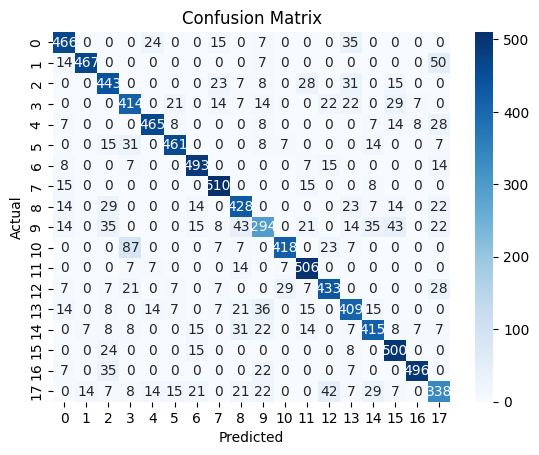

--------------------------------------------------  END  -------------------------------------------------- 

/content/MLmodels/ZSL_Predicted_Class_Train_Gradient Boosting_1.0.csv
Accuracy: 100.00 %
Log Loss: 0.00 %
Cohen's Kappa Score: 100.00 %

classification_report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       549
           1       1.00      1.00      1.00       550
           2       1.00      1.00      1.00       560
           3       1.00      1.00      1.00       547
           4       1.00      1.00      1.00       557
           5       1.00      1.00      1.00       557
           6       1.00      1.00      1.00       541
           7       1.00      1.00      1.00       557
           8       1.00      1.00      1.00       537
           9       1.00      1.00      1.00       553
          10       1.00      1.00      1.00       555
          11       1.00      1.00      1.00       553
          12       1.00    

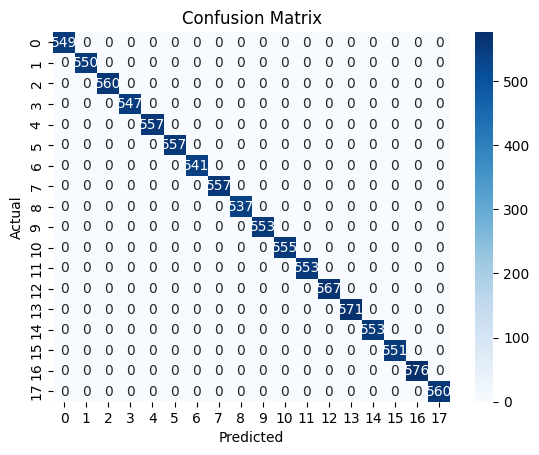

--------------------------------------------------  END  -------------------------------------------------- 

/content/MLmodels/ZSL_Predicted_Class_Train_SVM_0.992.csv
Accuracy: 99.83 %
Log Loss: 0.17 %
Cohen's Kappa Score: 99.82 %

classification_report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       549
           1       0.99      1.00      1.00       550
           2       1.00      1.00      1.00       560
           3       0.99      0.99      0.99       547
           4       1.00      1.00      1.00       557
           5       1.00      1.00      1.00       557
           6       1.00      1.00      1.00       541
           7       1.00      1.00      1.00       557
           8       1.00      1.00      1.00       537
           9       1.00      1.00      1.00       553
          10       1.00      1.00      1.00       555
          11       1.00      1.00      1.00       553
          12       0.99      0.99      0.

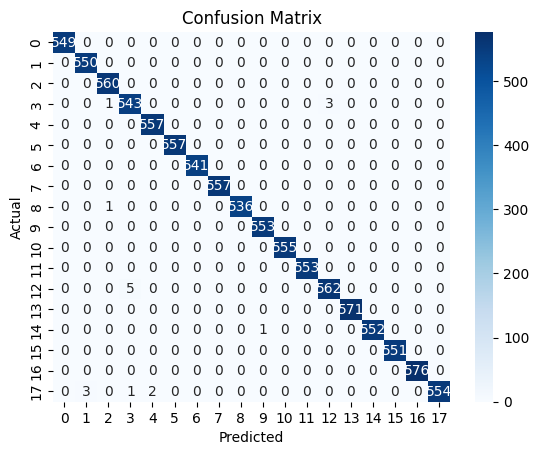

--------------------------------------------------  END  -------------------------------------------------- 

/content/MLmodels/ZSL_Predicted_Class_Train_Random Forest_1.0.csv
Accuracy: 100.00 %
Log Loss: 0.00 %
Cohen's Kappa Score: 100.00 %

classification_report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       549
           1       1.00      1.00      1.00       550
           2       1.00      1.00      1.00       560
           3       1.00      1.00      1.00       547
           4       1.00      1.00      1.00       557
           5       1.00      1.00      1.00       557
           6       1.00      1.00      1.00       541
           7       1.00      1.00      1.00       557
           8       1.00      1.00      1.00       537
           9       1.00      1.00      1.00       553
          10       1.00      1.00      1.00       555
          11       1.00      1.00      1.00       553
          12       1.00      1.

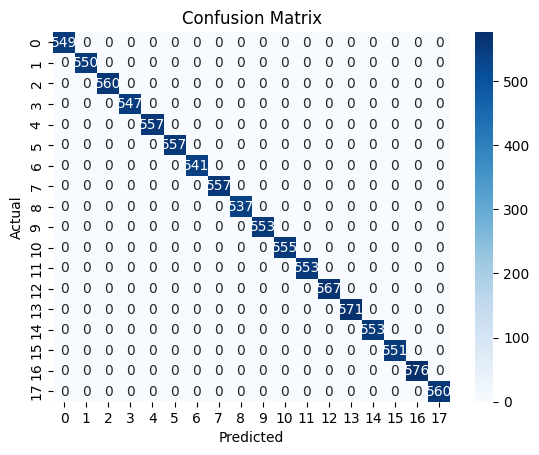

--------------------------------------------------  END  -------------------------------------------------- 

/content/MLmodels/ZSL_Predicted_Class_Test_AdaBoost_0.4864.csv
Accuracy: 67.10 %
Log Loss: 32.90 %
Cohen's Kappa Score: 65.17 %

classification_report:
              precision    recall  f1-score   support

           0       0.99      0.87      0.92       547
           1       0.93      0.91      0.92       538
           2       0.00      0.00      0.00       555
           3       0.47      0.76      0.58       550
           4       0.94      0.94      0.94       545
           5       0.97      0.91      0.94       543
           6       0.69      0.84      0.76       544
           7       0.96      0.95      0.95       548
           8       0.21      0.87      0.34       551
           9       0.40      0.03      0.05       544
          10       0.77      0.55      0.64       549
          11       0.97      0.55      0.70       541
          12       0.66      0.63  

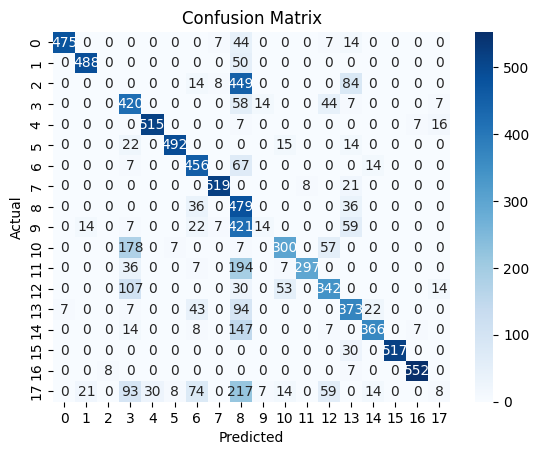

--------------------------------------------------  END  -------------------------------------------------- 

/content/MLmodels/ZSL_Predicted_Class_Train_AdaBoost_0.5031.csv
Accuracy: 66.93 %
Log Loss: 33.07 %
Cohen's Kappa Score: 65.00 %

classification_report:
              precision    recall  f1-score   support

           0       0.96      0.89      0.92       549
           1       0.92      0.88      0.90       550
           2       0.12      0.00      0.00       560
           3       0.46      0.74      0.56       547
           4       0.92      0.96      0.93       557
           5       0.99      0.91      0.95       557
           6       0.63      0.84      0.72       541
           7       0.92      0.94      0.93       557
           8       0.21      0.89      0.35       537
           9       0.20      0.01      0.01       553
          10       0.86      0.59      0.70       555
          11       0.95      0.59      0.73       553
          12       0.68      0.60 

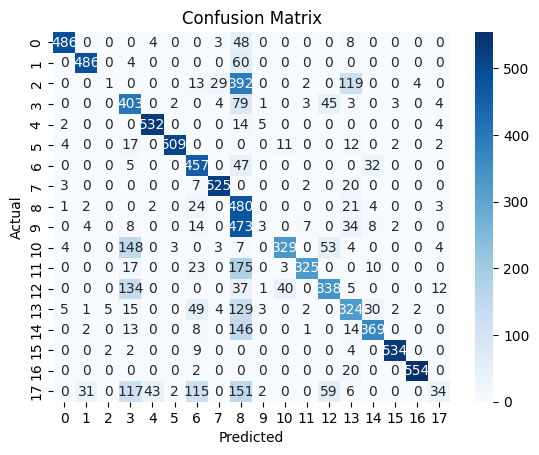

--------------------------------------------------  END  -------------------------------------------------- 

/content/MLmodels/ZSL_Predicted_Class_Test_SVM_0.9431.csv
Accuracy: 97.19 %
Log Loss: 2.81 %
Cohen's Kappa Score: 97.02 %

classification_report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       547
           1       1.00      1.00      1.00       538
           2       0.92      0.95      0.93       555
           3       0.95      1.00      0.98       550
           4       0.97      0.99      0.98       545
           5       1.00      1.00      1.00       543
           6       0.92      1.00      0.96       544
           7       0.99      1.00      0.99       548
           8       0.95      0.97      0.96       551
           9       0.95      0.87      0.91       544
          10       1.00      0.93      0.97       549
          11       1.00      0.96      0.98       541
          12       0.97      0.97      0.

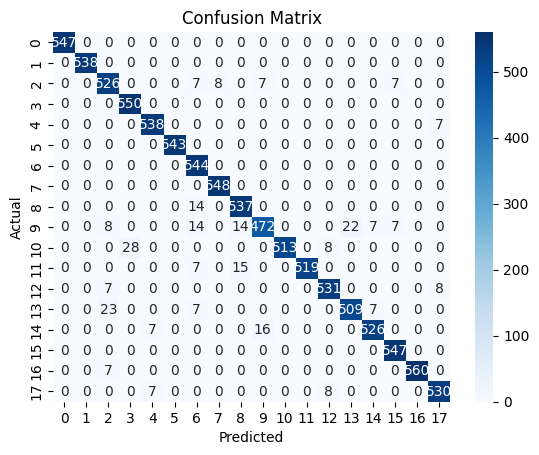

--------------------------------------------------  END  -------------------------------------------------- 

/content/MLmodels/ZSL_Predicted_Class_Train_Naive Bayes_0.855.csv
Accuracy: 91.84 %
Log Loss: 8.16 %
Cohen's Kappa Score: 91.35 %

classification_report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       549
           1       0.95      1.00      0.97       550
           2       0.96      0.84      0.89       560
           3       0.89      0.90      0.89       547
           4       0.93      0.98      0.96       557
           5       1.00      0.99      1.00       557
           6       0.91      0.99      0.95       541
           7       0.96      0.99      0.97       557
           8       0.92      0.82      0.87       537
           9       0.91      0.65      0.76       553
          10       0.97      0.90      0.93       555
          11       0.96      0.99      0.97       553
          12       0.83      0.93

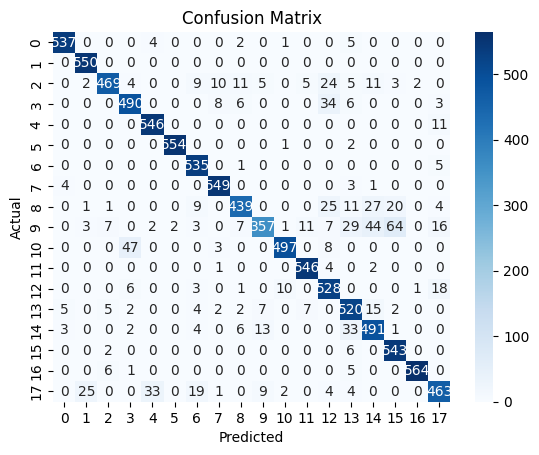

--------------------------------------------------  END  -------------------------------------------------- 

/content/MLmodels/ZSL_Predicted_Class_Train_XGBoost_1.0.csv
Accuracy: 100.00 %
Log Loss: 0.00 %
Cohen's Kappa Score: 100.00 %

classification_report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       549
           1       1.00      1.00      1.00       550
           2       1.00      1.00      1.00       560
           3       1.00      1.00      1.00       547
           4       1.00      1.00      1.00       557
           5       1.00      1.00      1.00       557
           6       1.00      1.00      1.00       541
           7       1.00      1.00      1.00       557
           8       1.00      1.00      1.00       537
           9       1.00      1.00      1.00       553
          10       1.00      1.00      1.00       555
          11       1.00      1.00      1.00       553
          12       1.00      1.00    

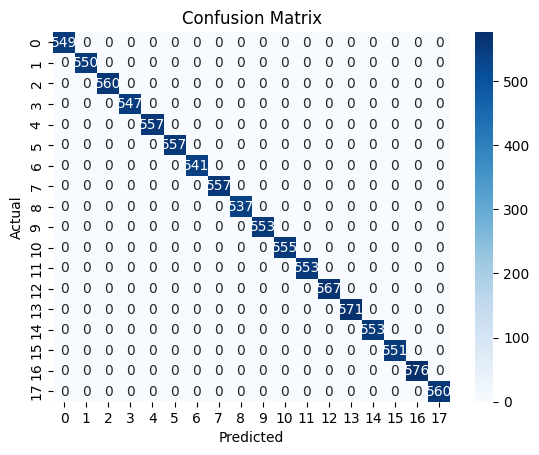

--------------------------------------------------  END  -------------------------------------------------- 

/content/MLmodels/ZSL_Predicted_Class_Test_k-NN_0.8498.csv
Accuracy: 91.87 %
Log Loss: 8.13 %
Cohen's Kappa Score: 91.39 %

classification_report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       547
           1       0.81      1.00      0.90       538
           2       0.76      0.88      0.81       555
           3       0.90      0.86      0.88       550
           4       0.95      0.97      0.96       545
           5       0.97      1.00      0.99       543
           6       0.89      1.00      0.94       544
           7       0.93      0.99      0.96       548
           8       0.96      0.89      0.92       551
           9       0.82      0.79      0.80       544
          10       1.00      0.85      0.92       549
          11       0.97      0.96      0.96       541
          12       0.86      0.90      0

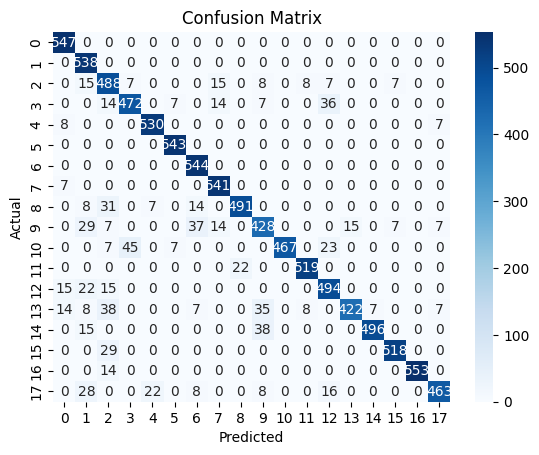

--------------------------------------------------  END  -------------------------------------------------- 

/content/MLmodels/ZSL_Predicted_Class_Train_k-NN_0.9277.csv
Accuracy: 95.89 %
Log Loss: 4.11 %
Cohen's Kappa Score: 95.65 %

classification_report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       549
           1       0.90      1.00      0.95       550
           2       0.89      0.92      0.90       560
           3       0.93      0.93      0.93       547
           4       0.96      0.98      0.97       557
           5       1.00      0.99      0.99       557
           6       0.97      1.00      0.98       541
           7       0.97      1.00      0.98       557
           8       0.95      0.93      0.94       537
           9       0.93      0.95      0.94       553
          10       1.00      0.91      0.95       555
          11       0.98      1.00      0.99       553
          12       0.94      0.97      

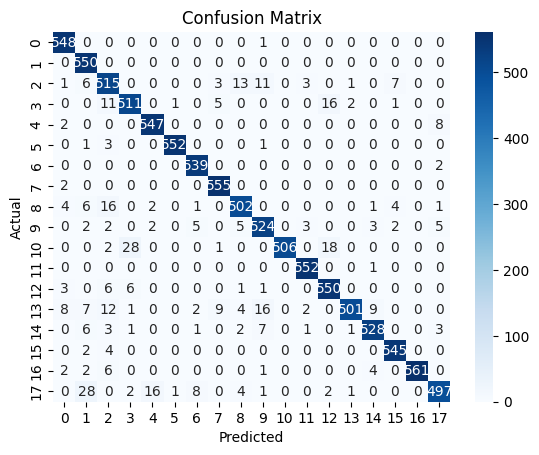

--------------------------------------------------  END  -------------------------------------------------- 

/content/MLmodels/ZSL_Predicted_Class_Test_Gradient Boosting_0.8962.csv
Accuracy: 95.19 %
Log Loss: 4.81 %
Cohen's Kappa Score: 94.91 %

classification_report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       547
           1       1.00      1.00      1.00       538
           2       0.92      0.93      0.93       555
           3       0.89      0.95      0.92       550
           4       0.97      0.95      0.96       545
           5       0.97      1.00      0.99       543
           6       0.96      1.00      0.98       544
           7       0.99      1.00      0.99       548
           8       0.90      0.93      0.92       551
           9       0.93      0.88      0.90       544
          10       0.94      0.89      0.92       549
          11       0.97      0.97      0.97       541
          12       0.93    

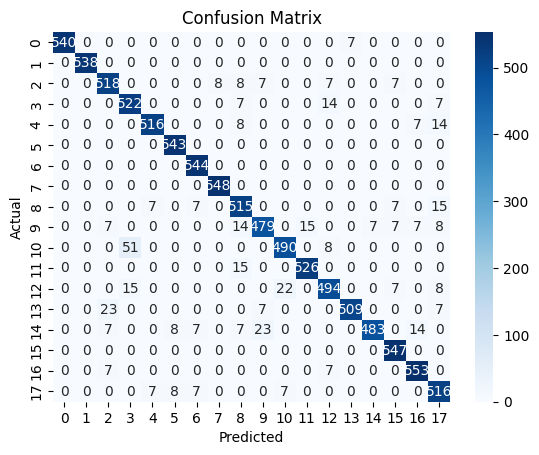

--------------------------------------------------  END  -------------------------------------------------- 

/content/MLmodels/ZSL_Predicted_Class_Test_LightGBM_0.9215.csv
Accuracy: 96.44 %
Log Loss: 3.56 %
Cohen's Kappa Score: 96.23 %

classification_report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       547
           1       1.00      1.00      1.00       538
           2       0.94      0.94      0.94       555
           3       0.88      0.99      0.93       550
           4       0.97      0.96      0.97       545
           5       0.97      0.99      0.98       543
           6       0.99      1.00      0.99       544
           7       0.96      0.99      0.97       548
           8       0.94      0.99      0.96       551
           9       0.93      0.91      0.92       544
          10       1.00      0.92      0.96       549
          11       0.99      0.97      0.98       541
          12       0.96      0.96   

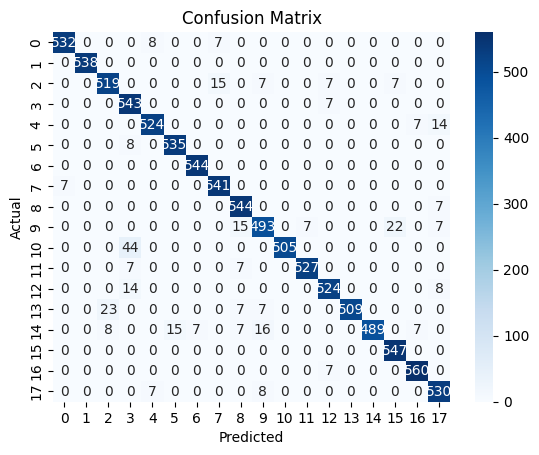

--------------------------------------------------  END  -------------------------------------------------- 

/content/MLmodels/ZSL_Predicted_Class_Train_Logistic Regression_1.0.csv
Accuracy: 100.00 %
Log Loss: 0.00 %
Cohen's Kappa Score: 100.00 %

classification_report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       549
           1       1.00      1.00      1.00       550
           2       1.00      1.00      1.00       560
           3       1.00      1.00      1.00       547
           4       1.00      1.00      1.00       557
           5       1.00      1.00      1.00       557
           6       1.00      1.00      1.00       541
           7       1.00      1.00      1.00       557
           8       1.00      1.00      1.00       537
           9       1.00      1.00      1.00       553
          10       1.00      1.00      1.00       555
          11       1.00      1.00      1.00       553
          12       1.00  

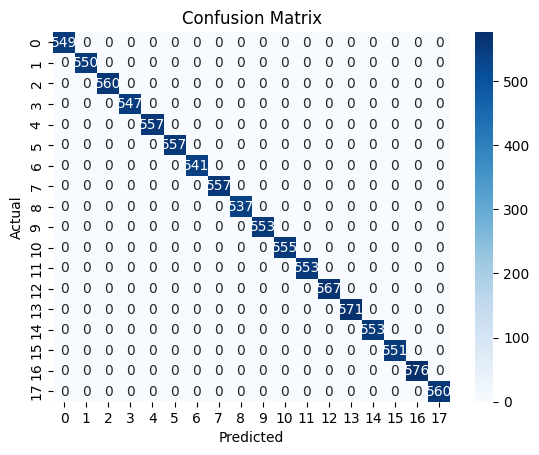

--------------------------------------------------  END  -------------------------------------------------- 

/content/MLmodels/ZSL_Predicted_Class_Test_Logistic Regression_0.9447.csv
Accuracy: 96.75 %
Log Loss: 3.25 %
Cohen's Kappa Score: 96.56 %

classification_report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       547
           1       1.00      0.99      0.99       538
           2       0.92      0.94      0.93       555
           3       0.89      0.97      0.93       550
           4       0.97      0.97      0.97       545
           5       1.00      1.00      1.00       543
           6       0.99      0.99      0.99       544
           7       0.96      1.00      0.98       548
           8       0.99      0.96      0.97       551
           9       0.93      0.92      0.93       544
          10       1.00      0.92      0.96       549
          11       0.99      1.00      0.99       541
          12       0.97  

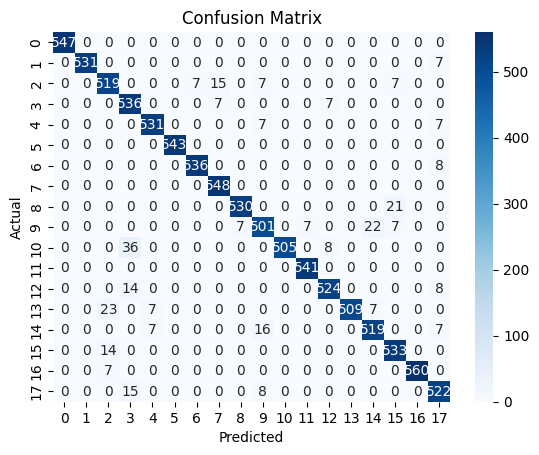

--------------------------------------------------  END  -------------------------------------------------- 

/content/MLmodels/ZSL_Predicted_Class_Test_Naive Bayes_0.8324.csv
Accuracy: 91.70 %
Log Loss: 8.30 %
Cohen's Kappa Score: 91.21 %

classification_report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       547
           1       0.96      1.00      0.98       538
           2       0.94      0.83      0.88       555
           3       0.89      0.96      0.92       550
           4       0.93      0.96      0.95       545
           5       1.00      1.00      1.00       543
           6       0.94      1.00      0.97       544
           7       0.96      1.00      0.98       548
           8       0.92      0.83      0.87       551
           9       0.94      0.58      0.72       544
          10       0.95      0.85      0.90       549
          11       0.93      0.96      0.95       541
          12       0.82      0.92

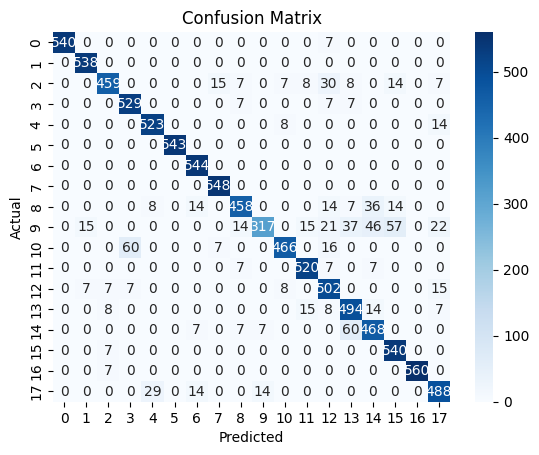

--------------------------------------------------  END  -------------------------------------------------- 

/content/MLmodels/ZSL_Predicted_Class_Test_Random Forest_0.9059.csv
Accuracy: 95.73 %
Log Loss: 4.27 %
Cohen's Kappa Score: 95.48 %

classification_report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       547
           1       0.97      0.99      0.98       538
           2       0.92      0.93      0.93       555
           3       0.93      0.95      0.94       550
           4       0.96      0.97      0.96       545
           5       1.00      1.00      1.00       543
           6       0.99      1.00      0.99       544
           7       0.96      1.00      0.98       548
           8       0.91      0.92      0.92       551
           9       0.94      0.82      0.87       544
          10       1.00      0.95      0.97       549
          11       0.99      0.96      0.97       541
          12       0.95      0.

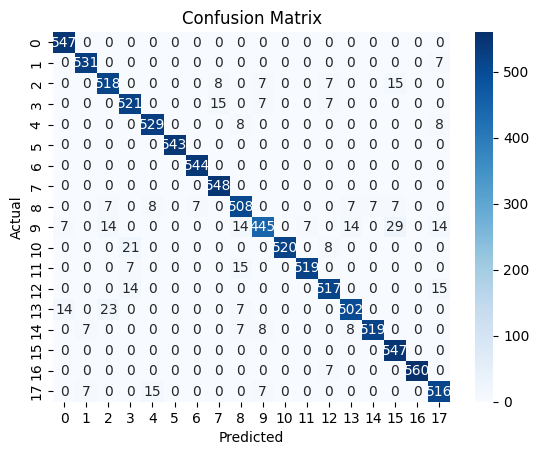

--------------------------------------------------  END  -------------------------------------------------- 

/content/MLmodels/ZSL_Predicted_Class_Train_LightGBM_1.0.csv
Accuracy: 100.00 %
Log Loss: 0.00 %
Cohen's Kappa Score: 100.00 %

classification_report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       549
           1       1.00      1.00      1.00       550
           2       1.00      1.00      1.00       560
           3       1.00      1.00      1.00       547
           4       1.00      1.00      1.00       557
           5       1.00      1.00      1.00       557
           6       1.00      1.00      1.00       541
           7       1.00      1.00      1.00       557
           8       1.00      1.00      1.00       537
           9       1.00      1.00      1.00       553
          10       1.00      1.00      1.00       555
          11       1.00      1.00      1.00       553
          12       1.00      1.00   

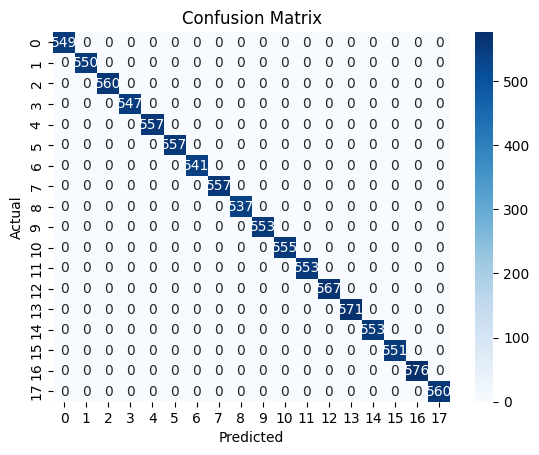

--------------------------------------------------  END  -------------------------------------------------- 

/content/MLmodels/ZSL_Predicted_Class_Test_XGBoost_0.9091.csv
Accuracy: 95.45 %
Log Loss: 4.55 %
Cohen's Kappa Score: 95.19 %

classification_report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99       547
           1       1.00      1.00      1.00       538
           2       0.93      0.92      0.93       555
           3       0.91      0.96      0.94       550
           4       0.93      0.93      0.93       545
           5       0.96      1.00      0.98       543
           6       0.96      1.00      0.98       544
           7       0.97      1.00      0.99       548
           8       0.93      0.93      0.93       551
           9       0.94      0.87      0.90       544
          10       0.99      0.92      0.95       549
          11       0.95      1.00      0.97       541
          12       0.92      0.93    

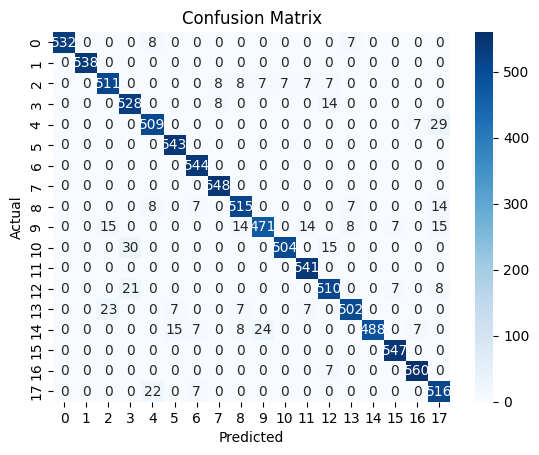

--------------------------------------------------  END  -------------------------------------------------- 

/content/MLmodels/ZSL_Predicted_Class_Train_Decision Tree_1.0.csv
Accuracy: 100.00 %
Log Loss: 0.00 %
Cohen's Kappa Score: 100.00 %

classification_report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       549
           1       1.00      1.00      1.00       550
           2       1.00      1.00      1.00       560
           3       1.00      1.00      1.00       547
           4       1.00      1.00      1.00       557
           5       1.00      1.00      1.00       557
           6       1.00      1.00      1.00       541
           7       1.00      1.00      1.00       557
           8       1.00      1.00      1.00       537
           9       1.00      1.00      1.00       553
          10       1.00      1.00      1.00       555
          11       1.00      1.00      1.00       553
          12       1.00      1.

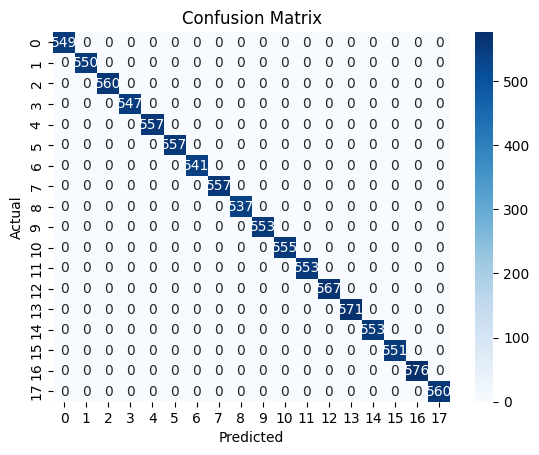

--------------------------------------------------  END  -------------------------------------------------- 



In [ ]:

import os, glob
import pandas as pd

for file_path in glob.glob(os.path.join('/content/MLmodels', '*.csv')):
    filename = os.path.basename(file_path)
    if filename.startswith("ZSL_Predicted_Class"):
        print(file_path)
        df = pd.read_csv(file_path)

        evaluate_model(df['actual_label'], df['ZSL Predicted Class'])

        print('-'*50, ' END ', '-'*50, '\n')

#         break

### Working with Unseen Dataset

In [ ]:
# import pickle
import joblib

idx_to_class = {v: k for k, v in train_data.class_indices.items()}
# idx_to_class

In [ ]:
import os
import csv
import time
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, cohen_kappa_score, classification_report, confusion_matrix
from keras.applications.vgg16 import VGG16, preprocess_input
from keras.preprocessing import image
from keras.models import Model
from keras.layers import Input, Dense, LeakyReLU

# Create a folder
def create_model_folder(folder_name="MLmodels"):
    """Create a folder to save trained models."""
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)
        print(f"Folder '{folder_name}' created.")
    else:
        print(f"Folder '{folder_name}' already exists.")
    return folder_name

# Build Generator
def build_generator(noise_dim, output_dim):
    input_noise = Input(shape=(noise_dim,))
    x = Dense(128, activation='relu')(input_noise)
    x = Dense(output_dim, activation='linear')(x)  # match feature vector size
    model = Model(input_noise, x)
    return model

# Build Discriminator
def build_discriminator(input_dim):
    input_feat = Input(shape=(input_dim,))
    x = Dense(128)(input_feat)
    x = LeakyReLU(alpha=0.2)(x)
    x = Dense(1, activation='sigmoid')(x)
    model = Model(input_feat, x)
    return model

# Feature Extractor
def build_feature_extractor():
    base_model = VGG16(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
    return base_model

# Create feature extractor once
feature_extractor = build_feature_extractor()

# Prediction generator
def unseen_prediction_generator(image_paths, model_paths):
    create_model_folder("Unseen_MLmodels")

    for model_file in model_paths:
        model_name = os.path.basename(model_file).split('_')[0]
        model = joblib.load(open(model_file, 'rb'))
        print(model.__class__.__name__)

        for img_path in image_paths:
            try:
                act_class = os.path.basename(os.path.dirname(img_path))

                # Preprocess image
                img = image.load_img(img_path, target_size=(224, 224))
                img_array = image.img_to_array(img)
                img_array = preprocess_input(img_array)
                img_array = np.expand_dims(img_array, axis=0)

                # Extract features & predict
                features = feature_extractor.predict(img_array, verbose=0)
                probs = model.predict_proba(features)[0]
                predicted_class = model.classes_[np.argmax(probs)]
                class_name = idx_to_class[predicted_class]
                confidence = np.max(probs)

                # Save CSV
                csv_file_path = os.path.join('Unseen_MLmodels', f"{model_name}_prediction_results_generator_unseen.csv")
                if not os.path.exists(csv_file_path):
                    with open(csv_file_path, mode='w', newline='') as f:
                        writer = csv.writer(f)
                        writer.writerow(["Image Path", "Actual Class", "Predicted Class", "Class Name", "Probability"])

                with open(csv_file_path, mode='a', newline='') as f:
                    writer = csv.writer(f)
                    writer.writerow([img_path, act_class, predicted_class, class_name, f"{confidence:.4f}"])

            except Exception as e:
                print(f"Error processing {img_path}: {e}")
                continue

        print('-'*50, ' END ', '-'*50, '\n')

# Evaluate model
def evaluate_model(test_labels, pred_labels):
    acc = accuracy_score(test_labels, pred_labels)
    loss = 1 - acc
    kappa = cohen_kappa_score(test_labels, pred_labels)

    print(f"Accuracy: {acc*100:.2f} %")
    print(f"Log Loss: {loss*100:.2f} %")
    print(f"Cohen's Kappa Score: {kappa*100:.2f} %\n")
    print("classification_report:")
    print(classification_report(test_labels, pred_labels))

    cm = confusion_matrix(test_labels, pred_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Predict for all images in a folder
import glob

img_dir = r'/content/sample_data/Trial_test/*/*'  # '../Dataset/artefact2/test/*/*'
image_paths = glob.glob(img_dir)
# print(image_paths)

model_path = [ 'MLmodels/SVM_0.9431.pkl',]

# model_path = ['MLmodels/AdaBoost_0.4864.pkl', 'MLmodels/Decision Tree_0.6936.pkl',
#               'MLmodels/Gradient Boosting_0.8962.pkl', 'MLmodels/k-NN_0.8498.pkl', 'MLmodels/LightGBM_0.9215.pkl',
#               'MLmodels/Logistic Regression_0.9447.pkl', 'MLmodels/Naive Bayes_0.8324.pkl',
#               'MLmodels/Random Forest_0.9059.pkl', 'MLmodels/SVM_0.9431.pkl', 'MLmodels/XGBoost_0.9091.pkl']
# print(model_path)

unseen_csv_file_path = "prediction_results_generator_unseen.csv"

# for result in prediction_generator(image_paths, model_path, csv_file_path=unseen_csv_file_path):
# #     print(result)
#     pass
unseen_prediction_generator(image_paths, model_path)


Folder 'Unseen_MLmodels' already exists.
SVC
--------------------------------------------------  END  -------------------------------------------------- 



In [ ]:
import zipfile
import os

# Path to your zip file
zip_path = r"/content/Trial_test.zip"

# Destination folder where you want to extract
extract_to = r"/content/sample_data"

# Create the output folder if it doesn't exist
os.makedirs(extract_to, exist_ok=True)

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print(f"Extracted to: {extract_to}")


Extracted to: /content/sample_data


In [ ]:

model = SentenceTransformer('all-MiniLM-L6-v2')

# img_dir = os.path.join('..', 'Dataset', 'artefact2', 'unseen', '*') # '../Dataset/artefact2/test/*'
img_dir = r'/content/sample_data/Trial_test'

# Get only subfolder names inside img_dir
image_class = sorted([os.path.basename(path) for path in glob.glob(os.path.join(img_dir, '*')) if os.path.isdir(path)])
print(image_class)
idx_to_unseen_class = {k: v for k, v in enumerate(image_class)}

words = list(idx_to_unseen_class.values()) # ['tiger', 'lion', 'cat', 'dog', 'truck']
print(words )
embeddings = model.encode(words, convert_to_tensor=True)

for unseen_csv_file_path in glob.glob(os.path.join(r'/content/sample_data/Unseen_MLmodels_complete_awa2_dataset', '*.csv')):
    print(unseen_csv_file_path)
    df = pd.read_csv(unseen_csv_file_path)
#     display(df.head())

    similar_wds = []

    for _, row in df.iterrows():
    #     print(row[-2])
        # Find top n similar
        query = model.encode(row[-2], convert_to_tensor=True)
        cosine_scores = util.cos_sim(query, embeddings)

        # Show top-3 results
        top_results = torch.topk(cosine_scores[0], k=5)
        wds, cos_scores = [], []
        for idx in top_results.indices:
    #         print(words[idx], float(cosine_scores[0][idx]))
            wds.append(words[idx])
            cos_scores.append(round(float(cosine_scores[0][idx])*100,2))
    #     break
        similar_wds.append((wds, cos_scores))

    df['similar_wds'] = similar_wds
#     display(df.head())

    df.to_csv(unseen_csv_file_path, index=False)
    print('-'*50, ' END ', '-'*50, '\n')


['chimpanzee', 'giant_panda', 'hippopotamus', 'humpback_whale', 'leopard', 'persian_cat', 'pig', 'raccoon', 'rat', 'seal']
['chimpanzee', 'giant_panda', 'hippopotamus', 'humpback_whale', 'leopard', 'persian_cat', 'pig', 'raccoon', 'rat', 'seal']
/content/sample_data/Unseen_MLmodels_complete_awa2_dataset/XGBoost_prediction_results_generator_unseen.csv


/tmp/ipython-input-418734360.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  query = model.encode(row[-2], convert_to_tensor=True)


--------------------------------------------------  END  -------------------------------------------------- 

/content/sample_data/Unseen_MLmodels_complete_awa2_dataset/Gradient Boosting_prediction_results_generator_unseen.csv


/tmp/ipython-input-418734360.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  query = model.encode(row[-2], convert_to_tensor=True)


--------------------------------------------------  END  -------------------------------------------------- 

/content/sample_data/Unseen_MLmodels_complete_awa2_dataset/Random Forest_prediction_results_generator_unseen.csv


...

--------------------------------------------------  END  -------------------------------------------------- 

/content/sample_data/Unseen_MLmodels_complete_awa2_dataset/Naive Bayes_prediction_results_generator_unseen.csv


/tmp/ipython-input-418734360.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  query = model.encode(row[-2], convert_to_tensor=True)


--------------------------------------------------  END  -------------------------------------------------- 

/content/sample_data/Unseen_MLmodels_complete_awa2_dataset/k-NN_prediction_results_generator_unseen.csv


/tmp/ipython-input-418734360.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  query = model.encode(row[-2], convert_to_tensor=True)


--------------------------------------------------  END  -------------------------------------------------- 



# Evaluation of generative model with Transformer#

/content/sample_data/Unseen_MLmodels_complete_awa2_dataset/XGBoost_prediction_results_generator_unseen.csv


/tmp/ipython-input-3328008590.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ActualClass = row[1]
/tmp/ipython-input-3328008590.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  SimilarWords = eval(row[-1])[0]


Accuracy: 59.55 %
Log Loss: 40.45 %
Cohen's Kappa Score: 53.21 %

classification_report:
              precision    recall  f1-score   support

           0       0.87      0.42      0.57       728
           1       1.00      0.26      0.41       874
           2       1.00      0.07      0.13       684
           3       0.85      0.90      0.87       709
           4       0.32      0.95      0.47       720
           5       0.91      0.71      0.80       747
           6       0.78      0.98      0.87       571
           8       0.00      0.00      0.00         0

    accuracy                           0.60      5033
   macro avg       0.72      0.54      0.52      5033
weighted avg       0.82      0.60      0.58      5033



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


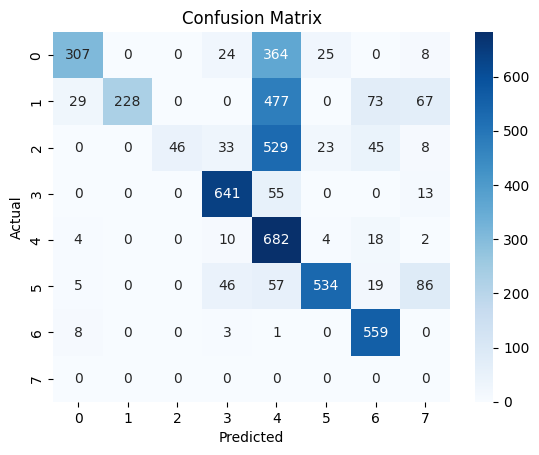

--------------------------------------------------  END  -------------------------------------------------- 

/content/sample_data/Unseen_MLmodels_complete_awa2_dataset/Gradient Boosting_prediction_results_generator_unseen.csv


/tmp/ipython-input-3328008590.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ActualClass = row[1]
/tmp/ipython-input-3328008590.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  SimilarWords = eval(row[-1])[0]


Accuracy: 51.08 %
Log Loss: 48.92 %
Cohen's Kappa Score: 45.76 %

classification_report:
              precision    recall  f1-score   support

           0       0.85      0.61      0.71       728
           1       1.00      0.20      0.33       874
           2       1.00      0.06      0.12       684
           3       0.95      0.95      0.95       709
           4       0.30      0.68      0.41       720
           5       0.57      0.74      0.64       747
           6       0.32      0.95      0.48       713
           7       1.00      0.37      0.54       512
           8       0.52      0.97      0.68       310
           9       1.00      0.02      0.03       988

    accuracy                           0.51      6985
   macro avg       0.75      0.56      0.49      6985
weighted avg       0.77      0.51      0.46      6985



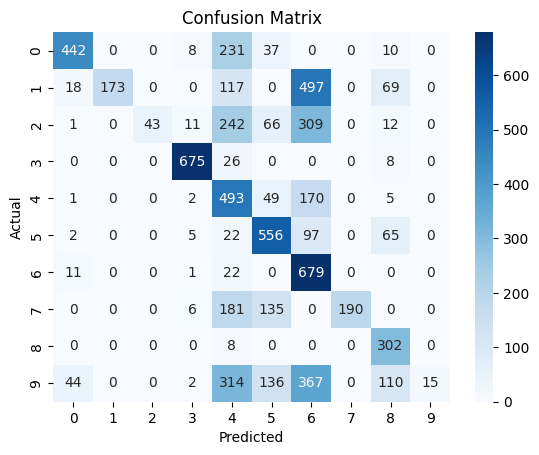

--------------------------------------------------  END  -------------------------------------------------- 

/content/sample_data/Unseen_MLmodels_complete_awa2_dataset/Random Forest_prediction_results_generator_unseen.csv


/tmp/ipython-input-3328008590.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ActualClass = row[1]
/tmp/ipython-input-3328008590.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  SimilarWords = eval(row[-1])[0]


Accuracy: 50.24 %
Log Loss: 49.76 %
Cohen's Kappa Score: 44.68 %

classification_report:
              precision    recall  f1-score   support

           0       0.73      0.53      0.62       728
           1       1.00      0.12      0.22       874
           2       1.00      0.03      0.06       684
           3       0.99      0.90      0.94       709
           4       0.20      1.00      0.33       720
           5       0.91      0.83      0.87       747
           6       0.65      0.87      0.74       713
           7       1.00      0.24      0.39       512
           8       0.88      0.89      0.89       310
           9       0.00      0.00      0.00       988

    accuracy                           0.50      6985
   macro avg       0.74      0.54      0.51      6985
weighted avg       0.70      0.50      0.46      6985



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


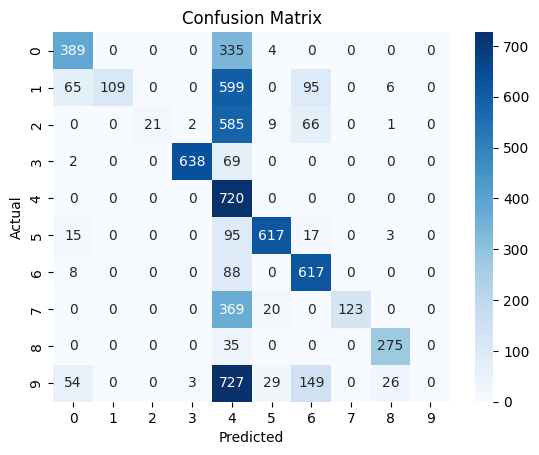

--------------------------------------------------  END  -------------------------------------------------- 

/content/sample_data/Unseen_MLmodels_complete_awa2_dataset/Decision Tree_prediction_results_generator_unseen.csv


/tmp/ipython-input-3328008590.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ActualClass = row[1]
/tmp/ipython-input-3328008590.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  SimilarWords = eval(row[-1])[0]


Accuracy: 47.32 %
Log Loss: 52.68 %
Cohen's Kappa Score: 41.86 %

classification_report:
              precision    recall  f1-score   support

           0       0.55      0.49      0.52       728
           1       1.00      0.16      0.28       874
           2       1.00      0.04      0.08       684
           3       0.88      0.90      0.89       709
           4       0.33      0.93      0.48       720
           5       0.54      0.37      0.44       747
           6       0.40      0.86      0.54       713
           7       0.82      0.55      0.66       512
           8       0.30      0.93      0.45       310
           9       1.00      0.00      0.01       988

    accuracy                           0.47      6985
   macro avg       0.68      0.53      0.44      6985
weighted avg       0.72      0.47      0.41      6985



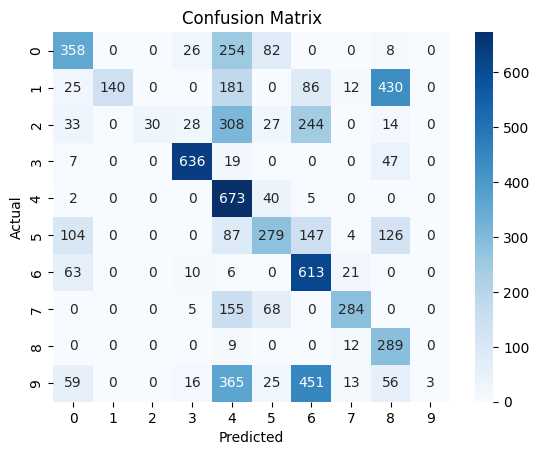

--------------------------------------------------  END  -------------------------------------------------- 

/content/sample_data/Unseen_MLmodels_complete_awa2_dataset/LightGBM_prediction_results_generator_unseen.csv


/tmp/ipython-input-3328008590.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ActualClass = row[1]
/tmp/ipython-input-3328008590.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  SimilarWords = eval(row[-1])[0]


Accuracy: 49.01 %
Log Loss: 50.99 %
Cohen's Kappa Score: 43.87 %

classification_report:
              precision    recall  f1-score   support

           0       0.81      0.49      0.61       728
           1       0.00      0.00      0.00       874
           2       1.00      0.08      0.14       684
           3       0.95      0.88      0.92       709
           4       0.21      0.91      0.35       720
           5       0.91      0.66      0.77       747
           6       0.96      0.98      0.97       713
           7       1.00      0.45      0.62       512
           8       0.24      1.00      0.39       310
           9       1.00      0.00      0.01       988

    accuracy                           0.49      6985
   macro avg       0.71      0.54      0.48      6985
weighted avg       0.72      0.49      0.45      6985



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


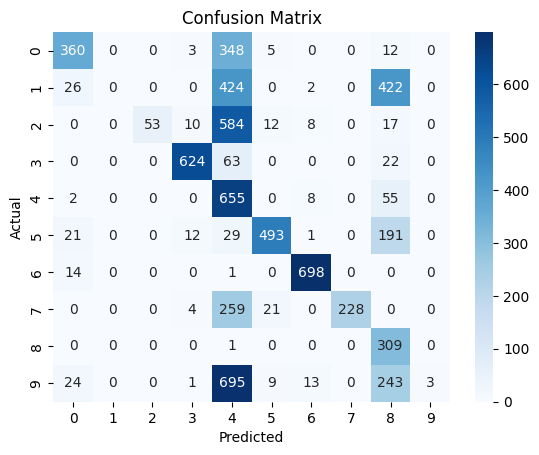

--------------------------------------------------  END  -------------------------------------------------- 

/content/sample_data/Unseen_MLmodels_complete_awa2_dataset/AdaBoost_prediction_results_generator_unseen.csv


/tmp/ipython-input-3328008590.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ActualClass = row[1]
/tmp/ipython-input-3328008590.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  SimilarWords = eval(row[-1])[0]


Accuracy: 58.28 %
Log Loss: 41.72 %
Cohen's Kappa Score: 53.51 %

classification_report:
              precision    recall  f1-score   support

           0       0.60      0.60      0.60       728
           1       1.00      0.42      0.59       874
           2       1.00      0.11      0.20       684
           3       0.63      0.68      0.65       709
           4       0.30      1.00      0.46       720
           5       0.56      0.99      0.71       747
           6       1.00      0.96      0.98       713
           7       1.00      0.05      0.09       512
           8       0.74      0.96      0.84       310
           9       1.00      0.24      0.39       988

    accuracy                           0.58      6985
   macro avg       0.78      0.60      0.55      6985
weighted avg       0.79      0.58      0.55      6985



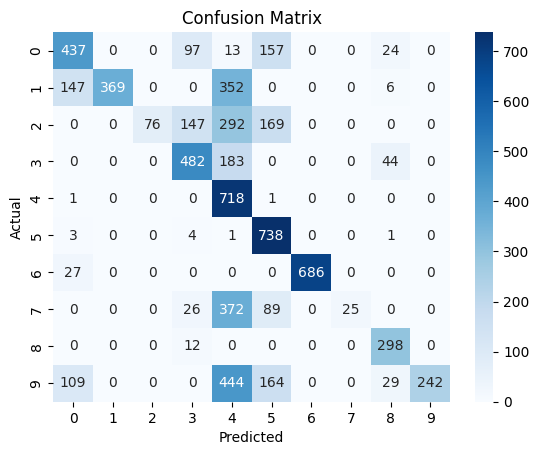

--------------------------------------------------  END  -------------------------------------------------- 

/content/sample_data/Unseen_MLmodels_complete_awa2_dataset/Logistic Regression_prediction_results_generator_unseen.csv


/tmp/ipython-input-3328008590.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ActualClass = row[1]
/tmp/ipython-input-3328008590.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  SimilarWords = eval(row[-1])[0]


Accuracy: 58.41 %
Log Loss: 41.59 %
Cohen's Kappa Score: 54.33 %

classification_report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       728
           1       1.00      0.01      0.03       874
           2       1.00      0.25      0.40       684
           3       0.51      1.00      0.68       709
           4       0.54      0.99      0.70       720
           5       0.83      0.80      0.82       747
           6       0.97      0.77      0.86       713
           7       0.57      0.51      0.54       512
           8       0.21      0.99      0.34       310
           9       1.00      0.10      0.18       988

    accuracy                           0.58      6985
   macro avg       0.75      0.63      0.54      6985
weighted avg       0.80      0.58      0.53      6985



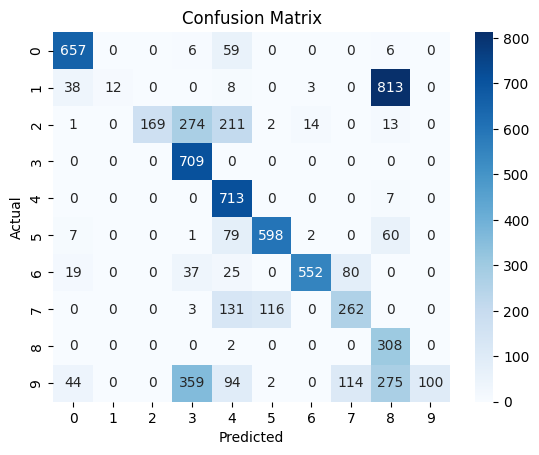

--------------------------------------------------  END  -------------------------------------------------- 

/content/sample_data/Unseen_MLmodels_complete_awa2_dataset/SVM_prediction_results_generator_unseen.csv


/tmp/ipython-input-3328008590.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ActualClass = row[1]
/tmp/ipython-input-3328008590.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  SimilarWords = eval(row[-1])[0]


Accuracy: 48.05 %
Log Loss: 51.95 %
Cohen's Kappa Score: 41.93 %

classification_report:
              precision    recall  f1-score   support

           0       1.00      0.00      0.00       728
           1       1.00      1.00      1.00       874
           2       0.00      0.00      0.00       684
           3       1.00      1.00      1.00       709
           4       0.00      0.00      0.00       720
           5       0.17      1.00      0.29       747
           6       1.00      1.00      1.00       713
           7       1.00      0.00      0.01       512
           8       1.00      1.00      1.00       310
           9       0.00      0.00      0.00       988

    accuracy                           0.48      6985
   macro avg       0.62      0.50      0.43      6985
weighted avg       0.57      0.48      0.41      6985



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


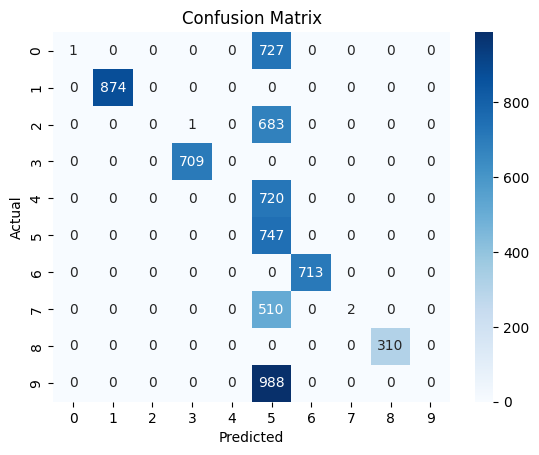

--------------------------------------------------  END  -------------------------------------------------- 

/content/sample_data/Unseen_MLmodels_complete_awa2_dataset/Naive Bayes_prediction_results_generator_unseen.csv


/tmp/ipython-input-3328008590.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ActualClass = row[1]
/tmp/ipython-input-3328008590.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  SimilarWords = eval(row[-1])[0]


Accuracy: 54.59 %
Log Loss: 45.41 %
Cohen's Kappa Score: 49.59 %

classification_report:
              precision    recall  f1-score   support

           0       0.96      0.50      0.65       728
           1       1.00      0.13      0.23       874
           2       1.00      0.01      0.01       684
           3       0.42      1.00      0.59       709
           4       0.41      1.00      0.58       720
           5       0.81      0.95      0.87       747
           6       0.44      0.96      0.61       713
           7       0.99      0.40      0.57       512
           8       0.76      0.99      0.86       310
           9       1.00      0.00      0.01       988

    accuracy                           0.55      6985
   macro avg       0.78      0.59      0.50      6985
weighted avg       0.79      0.55      0.45      6985



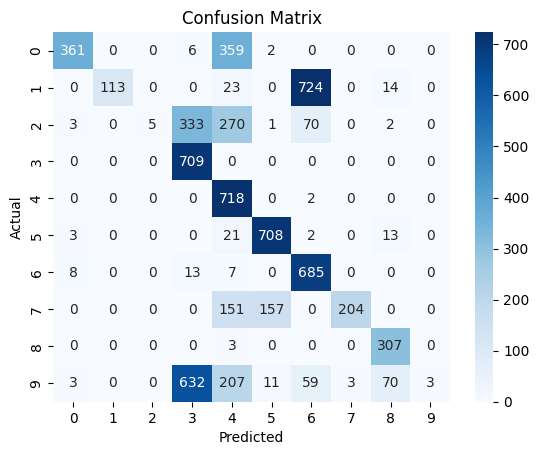

--------------------------------------------------  END  -------------------------------------------------- 

/content/sample_data/Unseen_MLmodels_complete_awa2_dataset/k-NN_prediction_results_generator_unseen.csv


/tmp/ipython-input-3328008590.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ActualClass = row[1]
/tmp/ipython-input-3328008590.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  SimilarWords = eval(row[-1])[0]


Accuracy: 58.14 %
Log Loss: 41.86 %
Cohen's Kappa Score: 54.02 %

classification_report:
              precision    recall  f1-score   support

           0       0.86      0.81      0.83       728
           1       1.00      0.04      0.08       874
           2       1.00      0.14      0.24       684
           3       0.58      1.00      0.73       709
           4       0.48      0.99      0.64       720
           5       0.95      0.56      0.70       747
           6       0.71      0.91      0.80       713
           7       0.74      0.79      0.76       512
           8       0.22      0.99      0.36       310
           9       1.00      0.14      0.25       988

    accuracy                           0.58      6985
   macro avg       0.75      0.64      0.54      6985
weighted avg       0.80      0.58      0.53      6985



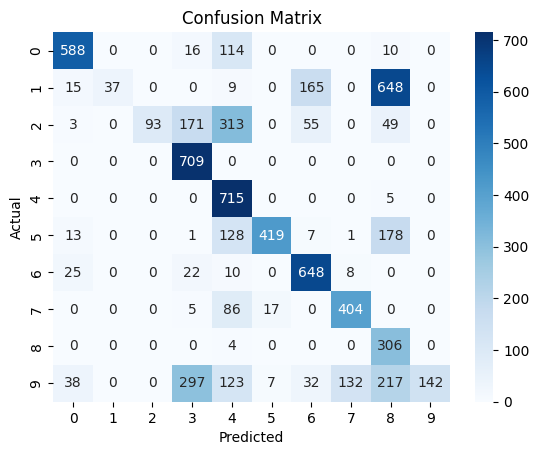

--------------------------------------------------  END  -------------------------------------------------- 



In [ ]:
for unseen_csv_file_path in glob.glob(os.path.join(r'/content/sample_data/Unseen_MLmodels_complete_awa2_dataset', '*.csv')):
    print(unseen_csv_file_path)
    df = pd.read_csv(unseen_csv_file_path)
    zsl_classes, unseen_class = [], []

    for _, row in df.iterrows():
        ActualClass = row[1]
        SimilarWords = eval(row[-1])[0]

        if ActualClass in SimilarWords:
            zsl_classes.append(words.index(ActualClass))
            unseen_class.append(words.index(ActualClass))
        else:
            zsl_classes.append(words.index(SimilarWords[0]))
            unseen_class.append(words.index(ActualClass))

    df['ZSL Predicted Class'] = zsl_classes
    df['ZSL Unseen Class'] = unseen_class
#     display(df.head())

    test_labels, pred_labels = df['ZSL Unseen Class'], df['ZSL Predicted Class']
    evaluate_model(test_labels, pred_labels)

    df.to_csv(unseen_csv_file_path, index=False)
    print('-'*50, ' END ', '-'*50, '\n')

# Evaluation of Generative model with Bert#

In [ ]:
import torch
import glob
import os
import pandas as pd
from transformers import BertTokenizer, BertModel
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm  # progress bar


In [ ]:
# -----------------
# Load BERT model & tokenizer
# -----------------
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')
bert_model.eval()

# -----------------
# Function to get mean pooled BERT embeddings for a list of texts
# -----------------
def get_bert_embeddings_batch(texts, batch_size=32):
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        inputs = tokenizer(batch_texts, return_tensors='pt', truncation=True,
                           padding=True, max_length=128)
        with torch.no_grad():
            outputs = bert_model(**inputs)
        batch_embeds = outputs.last_hidden_state.mean(dim=1)  # mean pooling
        all_embeddings.append(batch_embeds)
    return torch.cat(all_embeddings, dim=0)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [ ]:

# -----------------
# Prepare unseen class words
# -----------------
img_dir = r'/content/sample_data/Trial_test'
image_class = sorted([os.path.basename(path) for path in glob.glob(os.path.join(img_dir, '*')) if os.path.isdir(path)])
print("Image classes:", image_class)

words = list(image_class)
word_embeddings = get_bert_embeddings_batch(words)


Image classes: ['chimpanzee', 'giant_panda', 'hippopotamus', 'humpback_whale', 'leopard', 'persian_cat', 'pig', 'raccoon', 'rat', 'seal']


In [ ]:


# -----------------
# Loop through CSVs
# -----------------
for unseen_csv_file_path in glob.glob(os.path.join(r'/content/sample_data/Unseen_MLmodels_complete_awa2_dataset', '*.csv')):
    print(f"Processing: {unseen_csv_file_path}")
    df = pd.read_csv(unseen_csv_file_path)

    # Extract all query texts from the CSV
    query_texts = df.iloc[:, -2].tolist()

    # Compute embeddings in batches
    query_embeddings = get_bert_embeddings_batch(query_texts)

    # Compute cosine similarity (matrix form for speed)
    cosine_scores_matrix = cosine_similarity(query_embeddings.numpy(),
                                             word_embeddings.numpy())

    # Get top-5 matches for each query
    similar_wds = []
    for row_scores in cosine_scores_matrix:
        top_indices = row_scores.argsort()[::-1][:5]
        wds = [words[idx] for idx in top_indices]
        cos_scores = [round(row_scores[idx] * 100, 2) for idx in top_indices]
        similar_wds.append((wds, cos_scores))

    df['similar_wds'] = similar_wds
    df.to_csv(unseen_csv_file_path, index=False)
    print('-'*50, ' END ', '-'*50)


Processing: /content/sample_data/Unseen_MLmodels_complete_awa2_dataset/XGBoost_prediction_results_generator_unseen.csv
--------------------------------------------------  END  --------------------------------------------------
Processing: /content/sample_data/Unseen_MLmodels_complete_awa2_dataset/Gradient Boosting_prediction_results_generator_unseen.csv
--------------------------------------------------  END  --------------------------------------------------
Processing: /content/sample_data/Unseen_MLmodels_complete_awa2_dataset/Random Forest_prediction_results_generator_unseen.csv
--------------------------------------------------  END  --------------------------------------------------
Processing: /content/sample_data/Unseen_MLmodels_complete_awa2_dataset/Decision Tree_prediction_results_generator_unseen.csv
--------------------------------------------------  END  --------------------------------------------------
Processing: /content/sample_data/Unseen_MLmodels_complete_awa2_dataset

/content/sample_data/Unseen_MLmodels_complete_awa2_dataset/XGBoost_prediction_results_generator_unseen.csv


/tmp/ipython-input-3328008590.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ActualClass = row[1]
/tmp/ipython-input-3328008590.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  SimilarWords = eval(row[-1])[0]


Accuracy: 52.71 %
Log Loss: 47.29 %
Cohen's Kappa Score: 45.32 %

classification_report:
              precision    recall  f1-score   support

           0       1.00      0.01      0.02       728
           1       0.93      1.00      0.97       874
           2       1.00      0.00      0.01       684
           3       1.00      0.33      0.49       709
           4       0.50      0.99      0.66       720
           5       0.84      0.35      0.50       747
           6       0.27      0.98      0.43       571
           7       0.00      0.00      0.00         0

    accuracy                           0.53      5033
   macro avg       0.69      0.46      0.38      5033
weighted avg       0.81      0.53      0.46      5033



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


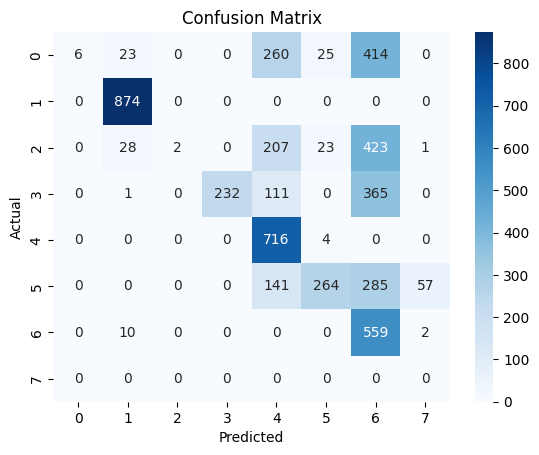

--------------------------------------------------  END  -------------------------------------------------- 

/content/sample_data/Unseen_MLmodels_complete_awa2_dataset/Gradient Boosting_prediction_results_generator_unseen.csv


/tmp/ipython-input-3328008590.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ActualClass = row[1]
/tmp/ipython-input-3328008590.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  SimilarWords = eval(row[-1])[0]


Accuracy: 57.48 %
Log Loss: 42.52 %
Cohen's Kappa Score: 52.37 %

classification_report:
              precision    recall  f1-score   support

           0       1.00      0.06      0.12       728
           1       0.96      1.00      0.98       874
           2       1.00      0.00      0.00       684
           3       1.00      0.25      0.40       709
           4       0.51      0.93      0.66       720
           5       0.45      0.46      0.45       747
           6       0.28      0.99      0.44       713
           7       0.51      0.14      0.22       512
           8       1.00      0.98      0.99       310
           9       1.00      0.84      0.91       988

    accuracy                           0.57      6985
   macro avg       0.77      0.56      0.52      6985
weighted avg       0.78      0.57      0.53      6985



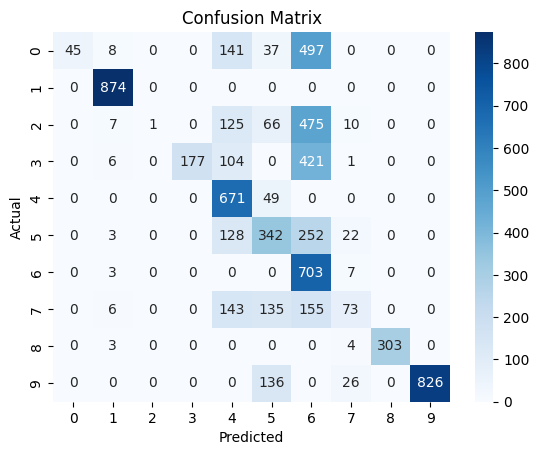

--------------------------------------------------  END  -------------------------------------------------- 

/content/sample_data/Unseen_MLmodels_complete_awa2_dataset/Random Forest_prediction_results_generator_unseen.csv


/tmp/ipython-input-3328008590.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ActualClass = row[1]
/tmp/ipython-input-3328008590.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  SimilarWords = eval(row[-1])[0]


Accuracy: 56.31 %
Log Loss: 43.69 %
Cohen's Kappa Score: 51.07 %

classification_report:
              precision    recall  f1-score   support

           0       1.00      0.01      0.02       728
           1       1.00      1.00      1.00       874
           2       1.00      0.01      0.03       684
           3       1.00      0.23      0.38       709
           4       0.37      1.00      0.54       720
           5       0.70      0.20      0.31       747
           6       0.31      0.97      0.47       713
           7       0.36      0.21      0.26       512
           8       1.00      0.91      0.95       310
           9       1.00      0.94      0.97       988

    accuracy                           0.56      6985
   macro avg       0.77      0.55      0.49      6985
weighted avg       0.79      0.56      0.50      6985



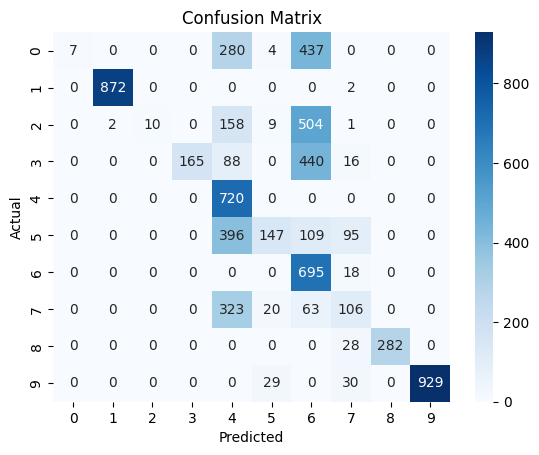

--------------------------------------------------  END  -------------------------------------------------- 

/content/sample_data/Unseen_MLmodels_complete_awa2_dataset/Decision Tree_prediction_results_generator_unseen.csv


/tmp/ipython-input-3328008590.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ActualClass = row[1]
/tmp/ipython-input-3328008590.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  SimilarWords = eval(row[-1])[0]


Accuracy: 53.79 %
Log Loss: 46.21 %
Cohen's Kappa Score: 48.38 %

classification_report:
              precision    recall  f1-score   support

           0       0.76      0.09      0.16       728
           1       0.94      0.97      0.96       874
           2       1.00      0.06      0.11       684
           3       1.00      0.25      0.40       709
           4       0.66      0.94      0.77       720
           5       0.44      0.25      0.32       747
           6       0.24      0.89      0.38       713
           7       0.17      0.22      0.19       512
           8       1.00      0.85      0.92       310
           9       1.00      0.75      0.86       988

    accuracy                           0.54      6985
   macro avg       0.72      0.53      0.51      6985
weighted avg       0.73      0.54      0.52      6985



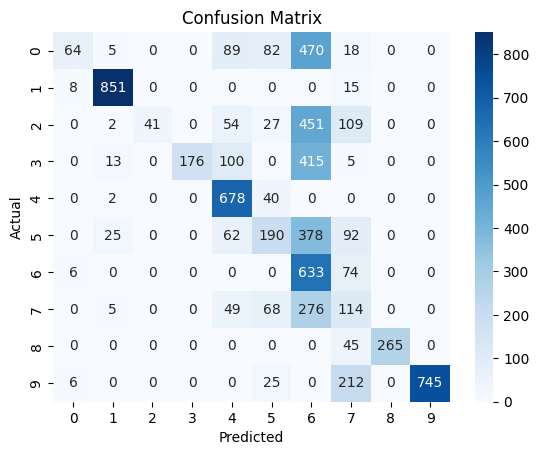

--------------------------------------------------  END  -------------------------------------------------- 

/content/sample_data/Unseen_MLmodels_complete_awa2_dataset/LightGBM_prediction_results_generator_unseen.csv


/tmp/ipython-input-3328008590.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ActualClass = row[1]
/tmp/ipython-input-3328008590.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  SimilarWords = eval(row[-1])[0]


Accuracy: 56.99 %
Log Loss: 43.01 %
Cohen's Kappa Score: 51.78 %

classification_report:
              precision    recall  f1-score   support

           0       1.00      0.00      0.01       728
           1       0.97      1.00      0.99       874
           2       1.00      0.00      0.00       684
           3       1.00      0.26      0.41       709
           4       0.47      1.00      0.64       720
           5       0.80      0.25      0.38       747
           6       0.25      0.99      0.40       713
           7       0.47      0.07      0.12       512
           8       1.00      0.97      0.99       310
           9       1.00      0.99      0.99       988

    accuracy                           0.57      6985
   macro avg       0.80      0.55      0.49      6985
weighted avg       0.81      0.57      0.51      6985



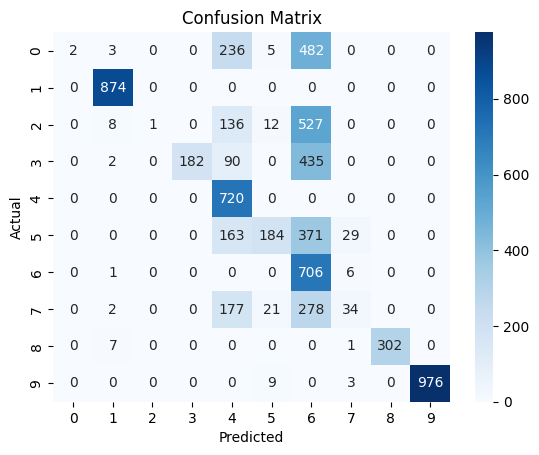

--------------------------------------------------  END  -------------------------------------------------- 

/content/sample_data/Unseen_MLmodels_complete_awa2_dataset/AdaBoost_prediction_results_generator_unseen.csv


/tmp/ipython-input-3328008590.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ActualClass = row[1]
/tmp/ipython-input-3328008590.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  SimilarWords = eval(row[-1])[0]


Accuracy: 56.18 %
Log Loss: 43.82 %
Cohen's Kappa Score: 50.82 %

classification_report:
              precision    recall  f1-score   support

           0       1.00      0.02      0.04       728
           1       0.71      1.00      0.83       874
           2       0.00      0.00      0.00       684
           3       1.00      0.42      0.59       709
           4       0.27      1.00      0.42       720
           5       0.34      0.39      0.36       747
           6       0.85      0.87      0.86       713
           7       0.05      0.01      0.01       512
           8       1.00      0.95      0.98       310
           9       1.00      0.82      0.90       988

    accuracy                           0.56      6985
   macro avg       0.62      0.55      0.50      6985
weighted avg       0.64      0.56      0.51      6985



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


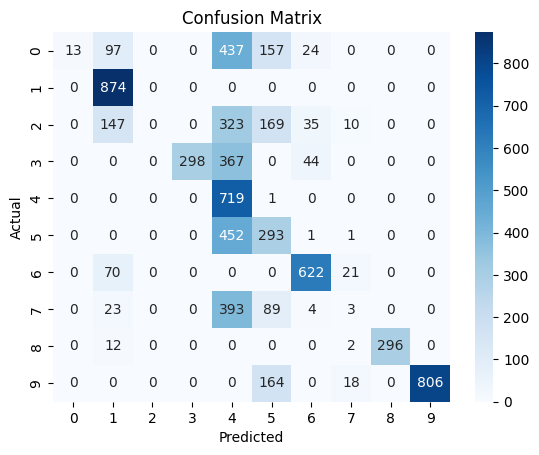

--------------------------------------------------  END  -------------------------------------------------- 

/content/sample_data/Unseen_MLmodels_complete_awa2_dataset/Logistic Regression_prediction_results_generator_unseen.csv


/tmp/ipython-input-3328008590.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ActualClass = row[1]
/tmp/ipython-input-3328008590.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  SimilarWords = eval(row[-1])[0]


Accuracy: 62.46 %
Log Loss: 37.54 %
Cohen's Kappa Score: 58.19 %

classification_report:
              precision    recall  f1-score   support

           0       0.13      0.02      0.04       728
           1       0.97      1.00      0.98       874
           2       1.00      0.23      0.37       684
           3       1.00      0.74      0.85       709
           4       0.46      1.00      0.63       720
           5       0.81      0.69      0.74       747
           6       0.47      0.88      0.61       713
           7       0.13      0.23      0.17       512
           8       1.00      0.97      0.99       310
           9       1.00      0.52      0.68       988

    accuracy                           0.62      6985
   macro avg       0.70      0.63      0.61      6985
weighted avg       0.71      0.62      0.61      6985



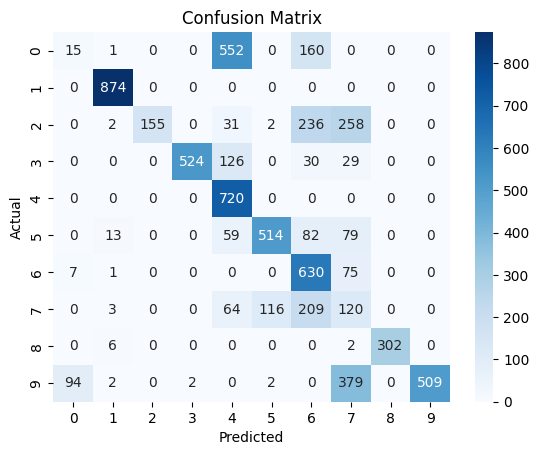

--------------------------------------------------  END  -------------------------------------------------- 

/content/sample_data/Unseen_MLmodels_complete_awa2_dataset/SVM_prediction_results_generator_unseen.csv


/tmp/ipython-input-3328008590.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ActualClass = row[1]
/tmp/ipython-input-3328008590.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  SimilarWords = eval(row[-1])[0]


Accuracy: 48.00 %
Log Loss: 52.00 %
Cohen's Kappa Score: 41.88 %

classification_report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       728
           1       1.00      1.00      1.00       874
           2       0.00      0.00      0.00       684
           3       1.00      1.00      1.00       709
           4       0.00      0.00      0.00       720
           5       0.17      1.00      0.29       747
           6       1.00      1.00      1.00       713
           7       0.00      0.00      0.00       512
           8       1.00      1.00      1.00       310
           9       0.00      0.00      0.00       988

    accuracy                           0.48      6985
   macro avg       0.42      0.50      0.43      6985
weighted avg       0.39      0.48      0.40      6985



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


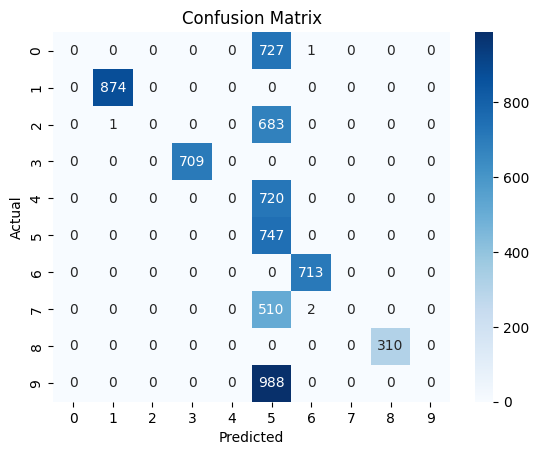

--------------------------------------------------  END  -------------------------------------------------- 

/content/sample_data/Unseen_MLmodels_complete_awa2_dataset/Naive Bayes_prediction_results_generator_unseen.csv


/tmp/ipython-input-3328008590.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ActualClass = row[1]
/tmp/ipython-input-3328008590.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  SimilarWords = eval(row[-1])[0]


Accuracy: 57.01 %
Log Loss: 42.99 %
Cohen's Kappa Score: 52.26 %

classification_report:
              precision    recall  f1-score   support

           0       0.67      0.01      0.02       728
           1       1.00      1.00      1.00       874
           2       1.00      0.01      0.01       684
           3       1.00      0.38      0.55       709
           4       0.68      1.00      0.81       720
           5       0.80      0.90      0.84       747
           6       0.37      1.00      0.54       713
           7       0.06      0.15      0.08       512
           8       1.00      0.99      1.00       310
           9       1.00      0.34      0.51       988

    accuracy                           0.57      6985
   macro avg       0.76      0.58      0.54      6985
weighted avg       0.78      0.57      0.54      6985



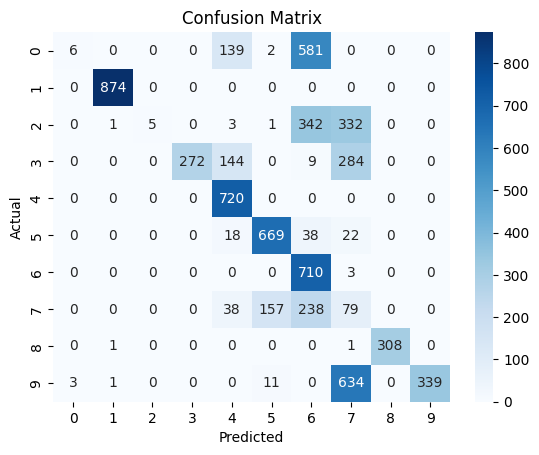

--------------------------------------------------  END  -------------------------------------------------- 

/content/sample_data/Unseen_MLmodels_complete_awa2_dataset/k-NN_prediction_results_generator_unseen.csv


/tmp/ipython-input-3328008590.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ActualClass = row[1]
/tmp/ipython-input-3328008590.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  SimilarWords = eval(row[-1])[0]


Accuracy: 52.90 %
Log Loss: 47.10 %
Cohen's Kappa Score: 47.47 %

classification_report:
              precision    recall  f1-score   support

           0       0.07      0.01      0.02       728
           1       0.88      1.00      0.93       874
           2       1.00      0.08      0.15       684
           3       1.00      0.36      0.53       709
           4       0.37      1.00      0.54       720
           5       0.91      0.32      0.47       747
           6       0.36      0.95      0.52       713
           7       0.11      0.14      0.12       512
           8       1.00      0.96      0.98       310
           9       1.00      0.50      0.67       988

    accuracy                           0.53      6985
   macro avg       0.67      0.53      0.49      6985
weighted avg       0.68      0.53      0.49      6985



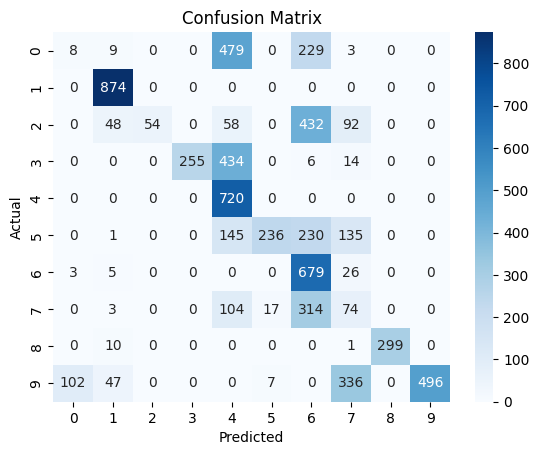

--------------------------------------------------  END  -------------------------------------------------- 



In [ ]:
for unseen_csv_file_path in glob.glob(os.path.join(r'/content/sample_data/Unseen_MLmodels_complete_awa2_dataset', '*.csv')):
    print(unseen_csv_file_path)
    df = pd.read_csv(unseen_csv_file_path)
    zsl_classes, unseen_class = [], []

    for _, row in df.iterrows():
        ActualClass = row[1]
        SimilarWords = eval(row[-1])[0]

        if ActualClass in SimilarWords:
            zsl_classes.append(words.index(ActualClass))
            unseen_class.append(words.index(ActualClass))
        else:
            zsl_classes.append(words.index(SimilarWords[0]))
            unseen_class.append(words.index(ActualClass))

    df['ZSL Predicted Class'] = zsl_classes
    df['ZSL Unseen Class'] = unseen_class
#     display(df.head())

    test_labels, pred_labels = df['ZSL Unseen Class'], df['ZSL Predicted Class']
    evaluate_model(test_labels, pred_labels)

    df.to_csv(unseen_csv_file_path, index=False)
    print('-'*50, ' END ', '-'*50, '\n')